In [11]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


In [12]:
import os

# --- PATH CONFIGURATION ---
# Set this to True if you are running in Google Colab
RUNNING_IN_COLAB = True

if RUNNING_IN_COLAB:
    # By default, Colab uploads go to the current directory (/content/)
    TRAIN_PATH = 'train_dataset.csv'
    TEST_PATH = 'test_dataset.csv'
    PREDS_DIR = '.'
else:
    # Default local paths
    TRAIN_PATH = '../datasets/train_dataset.csv'
    TEST_PATH = '../datasets/test_dataset.csv'
    PREDS_DIR = '../predictions'

os.makedirs(PREDS_DIR, exist_ok=True)


# Support Vector Regression (SVR) for Yield Prediction
This notebook documents the SVR implementation for predicting the continuous flow reactor's overall yield, incorporating feature engineering and hyperparameter tuning with 5-fold cross-validation.

In [13]:
# 1. Import libraries
import pandas as pd
import numpy as np
import math
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import KFold, GridSearchCV


In [14]:
# 2. Load train/test datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


In [15]:
# 3. Inspect data
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (150, 6)
Test shape: (50, 5)


In [16]:
# 4. Engineer residence_proxy
train_df['residence_proxy'] = train_df['length_m'] / train_df['flow_rate_L_min']
test_df['residence_proxy'] = test_df['length_m'] / test_df['flow_rate_L_min']

# 5. Engineer mean_T
train_df['mean_T'] = (train_df['inlet_temperature_K'] + train_df['jacket_temperature_K']) / 2
test_df['mean_T'] = (test_df['inlet_temperature_K'] + test_df['jacket_temperature_K']) / 2


In [17]:
# 6. Create exactly the 7 documented features
features = [
    'flow_rate_L_min',
    'concentration_mol_L',
    'inlet_temperature_K',
    'length_m',
    'jacket_temperature_K',
    'residence_proxy',
    'mean_T'
]
target = 'overall_yield'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]


In [18]:
# 7. Create StandardScaler + RBF SVR Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])


In [21]:
# 8. Hyperparameter tuning
# 9. 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'svr__C': [0.1, 1, 10, 50, 100, 150, 200, 300, 500],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
    'svr__epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr',
                                        SVR(C=300, epsilon=0.5, gamma=0.1))]),
             n_jobs=1,
             param_grid={'svr__C': [0.1, 1, 10, 50, 100, 150, 200, 300, 500],
                         'svr__epsilon': [0.01, 0.1, 0.5, 1.0, 2.0],
                         'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1,
                                        1.0]},
             scoring='neg_root_mean_squared_error')

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Ensure kf is exactly as requested
kf_manual = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmses = []
fold_rmses_clipped = []

oof_preds = np.zeros(len(y_train))
oof_preds_clipped = np.zeros(len(y_train))

for train_idx, val_idx in kf_manual.split(X_train):
    X_tr_f, X_val_f = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_f, y_val_f = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Standard pipeline parameters
    pipeline.set_params(**grid_search.best_params_)
    pipeline.fit(X_tr_f, y_tr_f)

    val_preds = pipeline.predict(X_val_f)
    val_preds_clipped = np.clip(val_preds, 0, 100)

    # Calculate RMSE manually by taking the square root of MSE
    fold_rmses.append(np.sqrt(mean_squared_error(y_val_f, val_preds)))
    fold_rmses_clipped.append(np.sqrt(mean_squared_error(y_val_f, val_preds_clipped)))

raw_oof_rmse = np.mean(fold_rmses)
clipped_oof_rmse = np.mean(fold_rmses_clipped)
clipping_improvement = raw_oof_rmse - clipped_oof_rmse
mean_fold_rmse = clipped_oof_rmse
std_fold_rmse = np.std(fold_rmses_clipped, ddof=1)

print(f"Raw RMSE = {raw_oof_rmse:.4f}")
print(f"Clipped RMSE = {clipped_oof_rmse:.4f}")
print(f"Clipping improvement = {clipping_improvement:.4f}")
print("\nClipped fold RMSEs:")
for rmse in fold_rmses_clipped:
    print(f"{rmse:.4f}")

print(f"\nMean CV RMSE = {mean_fold_rmse:.4f}")
print(f"Standard deviation = {std_fold_rmse:.4f}")

old_rmse = 21.702026860055522
difference = clipped_oof_rmse - old_rmse
percentage_difference = (difference / old_rmse) * 100

print(f"\nDifference from old benchmark = {difference:.4f}")
print(f"Percentage difference = {percentage_difference:.2f}%")

Raw RMSE = 23.1076
Clipped RMSE = 22.0950
Clipping improvement = 1.0126

Clipped fold RMSEs:
24.0814
19.9064
24.9621
20.0496
21.4757

Mean CV RMSE = 22.0950
Standard deviation = 2.3197

Difference from old benchmark = 0.3930
Percentage difference = 1.81%


In [23]:
# 14. Fit final model
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# 15. Generate 50 test predictions
preds = np.clip(best_model.predict(X_test), 0, 100)

# 16. Save SVR_predictions.csv
pd.DataFrame({'overall_yield': preds}).to_csv('SVR_predictions.csv', index=False)
print("Predictions saved successfully.")


Predictions saved successfully.


## Visualizations
The following plots help visualize the model's behavior and are highly recommended for the Phase 2 pitch.

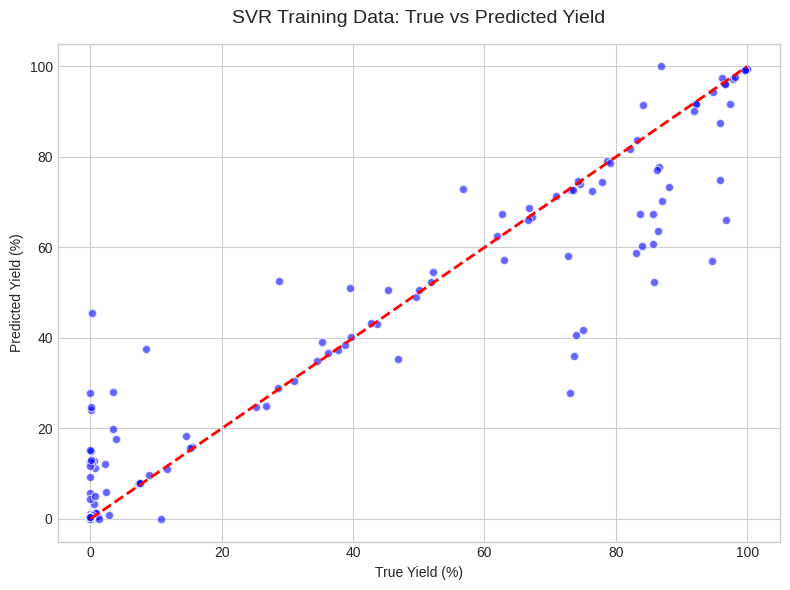

In [24]:
# Visualization: Training Fit (True vs Predicted)
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

# Training Fit (True vs Predicted)
y_train_pred = np.clip(best_model.predict(X_train), 0, 100)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='b', edgecolor='w')
plt.plot([0, 100], [0, 100], 'r--', lw=2) # Perfect prediction line
plt.title('SVR Training Data: True vs Predicted Yield', fontsize=14, pad=15)
plt.xlabel('True Yield (%)')
plt.ylabel('Predicted Yield (%)')

plt.tight_layout()
plt.show()
